# Convert EarthCARE BMA_FLX_2B to DGGS-Zarr

Broadband Radiometer (BBR) fluxes (using Multi-Spectral Imager (MSI) and Atmospheric Lidar (ATLID)) Level 2B (L2B) product

### Product Description

Providing instantaneous top-of-atmosphere (TOA) shortwave (SW) and longwave (LW) fluxes for the three BBR views (fore/nadir/aft) and combined, integrated spatially on four different integration domains (or spatial scales).

## Workflow
- Open EarthCARE Product
- Save the converted HEALPix data as DGGS-Zarr format following the
[zarr-conventions/dggs](https://github.com/zarr-conventions/dggs) specification,
and verify it can be re-opened with xdggs.

In [1]:
from pystac_client import Client
import earthcarekit as eck
import healpix_geo as hpxg
import numpy as np
import xarray as xr
import xdggs
import zarr
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import sys
sys.path.insert(0, '..')

from earthcare_dggs.convert import lonlat_to_healpix_cells
from earthcare_dggs.settings import ATLID_DEPTH, ELLIPSOID

## Search Catalog

In [2]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'


catalog = Client.open(catalog_url)

# Select one or more collection(s)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

# Select Product
PRODUCT = 'BMA_FLX_2B'
#PRODUCT = 'ACM_CAP_2B'

#search = catalog.search(
#    collections=EC_COLLECTION, 
#    filter="(productType = 'BMA_FLX_2B' and frame = 'E' and productVersion = 'BA')", 
#    bbox =  [-95, -22.5, -75, -2.5], # Filter by area 
#    datetime = ['2024-08-01T00:00:00Z', '2024-08-31T23:59:59Z'], # Filter by date
#    method = 'GET', # This is necessary 
#    max_items=1000 
#)
#items = list(search.items()) # Get all items as a list
#results = search.matched()

#print(f"{results} items found that matched the query.")
#print(f"Accessing {len(items)} items (limited by max_items).")

In [3]:
#print(items)

## Download Data

In [4]:
ORBIT = "01164E"
#ORBIT = "06109D"
eck.ecdownload(file_type=PRODUCT , orbit_and_frame=ORBIT)

#======================================================================#
#                       EarthCARE Download Tool                        #
#                         earthcarekit 0.15.3                          #
#======================================================================#
# Settings
# - is_download=True
# - is_overwrite=False
# - is_unzip=True
# - is_delete=True
# - is_create_subdirs=True
# - is_log=False
# - is_debug=False
# - is_export_results=False
# - idx_selected_input=None
# - config_filepath=</home/k/k204228/.config/earthcarekit/default_config.toml>
# - data_dirpath=</home/k/k204228/EarthCARE/data>

+----------------------------------------------------------------------+
| STEP 1/2 - Search products                       2026-06-18 08:52:48 |
+----------------------------------------------------------------------+

*[1/1] Search request: BMA_FLX_2B, frame=E, orbits=[1164]
 [1/1] Files found in collection 'EarthCAREL2Validated_MAAP': 1

List of files found (tot

## Search and verify downloaded Data

In [5]:
result = eck.search_product(file_type=PRODUCT , orbit_and_frame=ORBIT)
print(f"{PRODUCT }: {result.filepath[0]}")

BMA_FLX_2B: /home/k/k204228/EarthCARE/data/level2b/BMA_FLX_2B/2024/08/11/BA/ECA_EXBA_BMA_FLX_2B_20240811T185313Z_20250905T054137Z_01164E/ECA_EXBA_BMA_FLX_2B_20240811T185313Z_20250905T054137Z_01164E.h5


## Read

In [6]:
for file_type in [PRODUCT]:
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with xr.open_dataset(result.filepath[0], group="ScienceData/AssessmentResolution") as ds:
            print(f"\n{'='*60}")
            print(f"{file_type}")
            print(f"{'='*60}")
            print(f"Dimensions: {dict(ds.sizes)}")
            print(f"Lat: shape={ds['latitude'].shape}, range=[{float(ds['latitude'].min()):.1f}, {float(ds['latitude'].max()):.1f}]")
            print(f"Lon: shape={ds['longitude'].shape}, range=[{float(ds['longitude'].min()):.1f}, {float(ds['longitude'].max()):.1f}]")
            print(f"\n2D variables (along_track, vertical):")
            for v in ds.data_vars:
                if ds[v].dims == ("along_track", "vertical"):
                    print(f"  {v}: shape={ds[v].shape}, dtype={ds[v].dtype}")
    except Exception as e:
        print(f"\n{file_type}: not available ({e})")


BMA_FLX_2B
Dimensions: {'along_track': 5047, 'msi_channel': 7, 'primary_surfaces': 2, 'bbr_direction': 3}
Lat: shape=(5047,), range=[-23.3, 23.3]
Lon: shape=(5047,), range=[-78.8, -69.7]

2D variables (along_track, vertical):


In [7]:
result = eck.search_product(file_type=PRODUCT, orbit_and_frame=ORBIT)
with xr.open_dataset(result.filepath[0], group="ScienceData/AssessmentResolution") as ds:
    atl = ds.load()

print(f"Dimensions: {dict(atl.sizes)}")
print(f"Lat: [{float(atl['latitude'].min()):.1f}, {float(atl['latitude'].max()):.1f}]")
print(f"Lon: [{float(atl['longitude'].min()):.1f}, {float(atl['longitude'].max()):.1f}]")
print(f"\n1D variables (along_track, vertical):")
for v in atl.data_vars:
    if atl[v].dims == ("along_track",):
        print(f"  {v}: shape={atl[v].shape}")

Dimensions: {'along_track': 5047, 'msi_channel': 7, 'primary_surfaces': 2, 'bbr_direction': 3}
Lat: [-23.3, 23.3]
Lon: [-78.8, -69.7]

1D variables (along_track, vertical):
  cloud_cover: shape=(5047,)
  MSI_cloud_top_height_mean: shape=(5047,)
  MSI_cloud_top_height_error: shape=(5047,)
  ATLID_cloud_top_height: shape=(5047,)
  latitude: shape=(5047,)
  longitude: shape=(5047,)
  time: shape=(5047,)
  geoid_offset: shape=(5047,)
  solar_reference_level_height: shape=(5047,)
  thermal_reference_level_height: shape=(5047,)
  solar_combined_top_of_atmosphere_flux: shape=(5047,)
  solar_combined_top_of_atmosphere_flux_error: shape=(5047,)
  solar_combined_top_of_atmosphere_flux_quality_status: shape=(5047,)
  thermal_combined_top_of_atmosphere_flux: shape=(5047,)
  thermal_combined_top_of_atmosphere_flux_error: shape=(5047,)
  thermal_combined_top_of_atmosphere_flux_quality_status: shape=(5047,)
  quality_status: shape=(5047,)


In [8]:
prof_cell_ids = lonlat_to_healpix_cells(
    atl["longitude"].values, atl["latitude"].values,
    depth=ATLID_DEPTH, ellipsoid=ELLIPSOID,
)

unique_cells = np.unique(prof_cell_ids)
print(f"HEALPix depth {ATLID_DEPTH}: {len(atl.along_track)} profiles → {len(unique_cells)} unique cells")
print(f"Average profiles per cell: {len(atl.along_track) / len(unique_cells):.1f}")

# Add cell_ids as coordinate
atl_healpix = atl.assign_coords(cell_ids=("along_track", prof_cell_ids))
atl_healpix.attrs.update({
    "healpix_level": ATLID_DEPTH,
    "healpix_indexing": "nested",
    "healpix_ellipsoid": ELLIPSOID,
})

print(f"\nDataset with cell_ids coordinate:")
print(atl_healpix)

HEALPix depth 14: 5047 profiles → 5047 unique cells
Average profiles per cell: 1.0

Dataset with cell_ids coordinate:
<xarray.Dataset> Size: 3MB
Dimensions:                                                 (along_track: 5047,
                                                             msi_channel: 7,
                                                             primary_surfaces: 2,
                                                             bbr_direction: 3)
Coordinates:
    cell_ids                                                (along_track) uint64 40kB ...
Dimensions without coordinates: along_track, msi_channel, primary_surfaces,
                                bbr_direction
Data variables: (12/46)
    MSI_clear_radiance_mean                                 (along_track, msi_channel) float32 141kB ...
    MSI_cloud_radiance_mean                                 (along_track, msi_channel) float32 141kB ...
    MSI_allsky_radiance_mean                                (along_track, msi_

In [9]:
# Add metadata
atl_healpix.attrs.update({
    "source": "EarthCARE MSI L2A",
    "healpix_level": ATLID_DEPTH,
    "healpix_indexing": "nested",
    "healpix_ellipsoid": ELLIPSOID,
    "orbit_and_frame": ORBIT,
})

# Add xdggs index
atl_healpix = xdggs.decode(
    atl_healpix,
    grid_info=xdggs.HealpixInfo(level=ATLID_DEPTH, indexing_scheme="nested"),
)

## Save to DGGS ZARR

In [10]:
# Encode with xdggs convention
atl_encoded = xdggs.encode(atl_healpix, "xdggs")

# Write to Zarr
output_path = f"/work/ks1387/gw/data/obs/earthcare/earthcare_BMA_FLX_2B_{ORBIT}.zarr"
#output_path = f"earthcare_BMA_FLX_2B_{ORBIT}.zarr"
atl_encoded.to_zarr(output_path, mode="w", consolidated=True)

# Add DGGS Zarr convention metadata (compatible with legacy-converters format)
dggs_convention = {
    "uuid": "7b255807-140c-42ca-97f6-7a1cfecdbc38",
    "name": "dggs",
    "schema_url": "https://raw.githubusercontent.com/zarr-conventions/dggs/refs/tags/v1/schema.json",
    "spec_url": "https://github.com/zarr-conventions/dggs/blob/v1/README.md",
    "description": "Discrete Global Grid Systems convention for zarr",
}

dggs_meta = {
    "name": "healpix",
    "refinement_level": ATLID_DEPTH,
    "indexing_scheme": "nested",
    "ellipsoid": {
        "name": "wgs84",
        "semimajor_axis": 6378137.0,
        "inverse_flattening": 298.257223563,
    },
    "spatial_dimension": "cell_ids",
    "coordinate": "cell_ids",
    "compression": "none",
}

root = zarr.open_group(output_path, mode="r+")
root.attrs["zarr_conventions"] = [dggs_convention]
root.attrs["dggs"] = dggs_meta

print(f"Saved to {output_path}")
print(f"\nDGGS metadata: {dggs_meta}")

Saved to /work/ks1387/gw/data/obs/earthcare/earthcare_BMA_FLX_2B_01164E.zarr

DGGS metadata: {'name': 'healpix', 'refinement_level': 14, 'indexing_scheme': 'nested', 'ellipsoid': {'name': 'wgs84', 'semimajor_axis': 6378137.0, 'inverse_flattening': 298.257223563}, 'spatial_dimension': 'cell_ids', 'coordinate': 'cell_ids', 'compression': 'none'}


/home/k/k204228/.conda/envs/earthcare/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Plot Data

In [11]:
ds_healpix = xr.open_dataset("earthcare_BMA_FLX_2B_" +ORBIT +".zarr", consolidated=False)
ds_healpix

<xarray.Dataset> Size: 3MB
Dimensions:                                                 (along_track: 5047,
                                                             msi_channel: 7,
                                                             bbr_direction: 3,
                                                             primary_surfaces: 2)
Coordinates:
    cell_ids                                                (along_track) uint64 40kB ...
Dimensions without coordinates: along_track, msi_channel, bbr_direction,
                                primary_surfaces
Data variables: (12/46)
    MSI_clear_radiance_mean                                 (along_track, msi_channel) float32 141kB ...
    MSI_allsky_radiance_error                               (along_track, msi_channel) float32 141kB ...
    MSI_allsky_radiance_mean                                (along_track, msi_channel) float32 141kB ...
    MSI_clear_radiance_error                                (along_track, msi_channel) float32 141kB ...
    ATLID_cloud_top_height                                  (along_track) float32 20kB ...
    MSI_clear_radiance_quality_status                       (along_track, msi_channel) float32 141kB ...
    ...                                                      ...
    thermal_top_of_atmosphere_flux                          (along_track, bbr_direction) float32 61kB ...
    thermal_top_of_atmosphere_flux_error                    (along_track, bbr_direction) float32 61kB ...
    thermal_top_of_atmosphere_flux_quality_status           (along_track, bbr_direction) float32 61kB ...
    time                                                    (along_track) datetime64[ns] 40kB ...
    viewing_azimuth_angle                                   (along_track, bbr_direction) float32 61kB ...
    viewing_zenith_angle                                    (along_track, bbr_direction) float32 61kB ...
Attributes:
    healpix_level:      14
    healpix_indexing:   nested
    healpix_ellipsoid:  WGS84
    source:             EarthCARE MSI L2A
    orbit_and_frame:    01164E
    zarr_conventions:   [{'uuid': '7b255807-140c-42ca-97f6-7a1cfecdbc38', 'na...
    dggs:               {'name': 'healpix', 'refinement_level': 14, 'indexing...

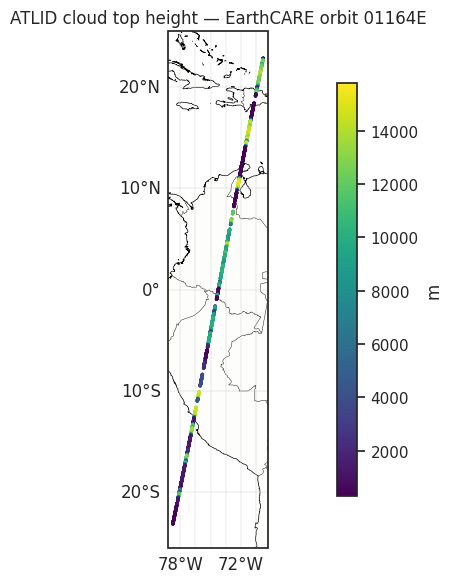

In [12]:
# Extract data
var      = ds_healpix["ATLID_cloud_top_height"].values
cell_ids = ds_healpix["cell_ids"].values

# Get lat/lon from cell_ids
theta, phi = hp.pix2ang(2**ds_healpix.attrs["healpix_level"], cell_ids.astype(int), nest=True)
lat = 90 - np.degrees(theta)
lon = np.degrees(phi)

# Plot
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})

#ax.coastlines(resolution="110m", linewidth=0.8)
#ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.1)
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
#ax.stock_img()

sc = ax.scatter(lon, lat, c=var, s=2, cmap="viridis",
                transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc, ax=ax, label=ds_healpix["ATLID_cloud_top_height"].attrs.get("units", ""),
             shrink=0.8)
ax.set_title("ATLID cloud top height — EarthCARE orbit 01164E")
plt.tight_layout()
plt.savefig("map.png")
plt.show()